##Imports

In [1]:
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import BertForQuestionAnswering, Trainer, TrainingArguments, pipeline

##Load + Tokenize

In [2]:
dataset = load_dataset("imdb")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(x):
    return tokenizer(x["text"], truncation=True, padding="max_length", max_length=128)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column("label", "labels")
dataset.set_format(type="torch", columns=["input_ids","attention_mask","labels"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


##Model + Trainer

In [3]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    num_train_epochs=1,
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"].select(range(2000)),
    eval_dataset=dataset["test"].select(range(500)),
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


##Train

In [4]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
50,0.039487
100,0.000227
150,0.000132
200,0.000100
250,0.000090


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=250, training_loss=0.008007206587120891, metrics={'train_runtime': 1917.8367, 'train_samples_per_second': 1.043, 'train_steps_per_second': 0.13, 'total_flos': 131555527680000.0, 'train_loss': 0.008007206587120891, 'epoch': 1.0})

##Loss Plot

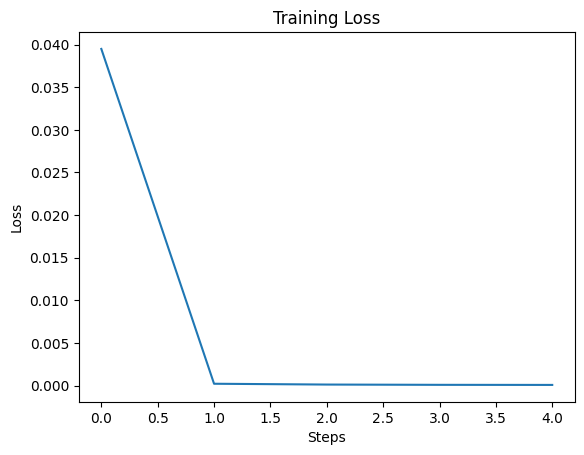

In [5]:
logs = trainer.state.log_history
losses = [x["loss"] for x in logs if "loss" in x]

plt.plot(losses)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

##Predictions

In [6]:
samples = ["Great movie", "Worst film ever", "Not bad"]

for s in samples:
    inputs = tokenizer(s, return_tensors="pt")
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()
    print(s, "->", "Positive" if pred==1 else "Negative")

Great movie -> Negative
Worst film ever -> Negative
Not bad -> Negative


##Load SQuAD

In [7]:
dataset_qa = load_dataset("squad")

##Tokenize + Labels

In [8]:
def preprocess(x):
    inputs = tokenizer(
        x["question"],
        x["context"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

    start_positions = []
    end_positions = []

    for ans in x["answers"]:
        if len(ans["answer_start"]) > 0:
            start = ans["answer_start"][0]
            end = start + len(ans["text"][0])
        else:
            start, end = 0, 0

        start_positions.append(start)
        end_positions.append(end)

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions

    return inputs

dataset_qa = dataset_qa.map(preprocess, batched=True)

dataset_qa.set_format(type="torch", columns=[
    "input_ids", "attention_mask", "start_positions", "end_positions"
])

##QA Model + Trainer

In [9]:
model_qa = BertForQuestionAnswering.from_pretrained("bert-base-uncased")

training_args_qa = TrainingArguments(
    output_dir="./qa_results",
    per_device_train_batch_size=4,
    num_train_epochs=1,
    report_to="none"
)

trainer_qa = Trainer(
    model=model_qa,
    args=training_args_qa,
    train_dataset=dataset_qa["train"].select(range(2000)),
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
qa_outputs.weight                          | MISSING    | 
qa_outputs.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

##Train QA

In [10]:
trainer_qa.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,5.548859


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=5.548859375, metrics={'train_runtime': 3918.0141, 'train_samples_per_second': 0.51, 'train_steps_per_second': 0.128, 'total_flos': 261296756736000.0, 'train_loss': 5.548859375, 'epoch': 1.0})

##QA Inference

In [11]:
qa_pipeline = pipeline("question-answering", model=model_qa, tokenizer=tokenizer)

In [12]:
res = qa_pipeline(
    question="Who developed BERT?",
    context="BERT was developed by Google researchers."
)

print("Q:", "Who developed BERT?")
print("A:", res["answer"])

Q: Who developed BERT?
A: BERT was developed by Google researchers
